In [ ]:
%cd ../..
# !pip install seaborn

/gpfs/data/schambralab/quantitativeRehabilitation/__lab_member_homes/victor/cvfm4rehab


In [23]:
from lmms_eval.tasks.strokerehab.utils_primitives import load_strokerehab_primitives_dataset
from data.utils_strokerehab import PrimitiveLabelUtils, DataPaths
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.4)

In [18]:
ds = load_strokerehab_primitives_dataset(filter_for_testset=True)

In [38]:
import numpy as np
import pandas as pd
ds = load_strokerehab_primitives_dataset(filter_for_testset=True)
ds = pd.DataFrame(ds['test'])
dss = load_strokerehab_primitives_dataset(filter_for_subsampled_testset=True)
dss = pd.DataFrame(dss['test'])

print(np.sum(ds['duration_s']) / 60.)  # total length in minutes
print(np.sum(dss['duration_s']) / 60.)  # total length

415.59191666666663
39.21016666666666


In [39]:
len(dss['duration_s'])

50

In [40]:
path_l = "S00047/S00047_shelf right side3_2.csv"

import os
len(PrimitiveLabelUtils.convert_labels_to_action_sequence(os.path.join(DataPaths.RAW_LABEL_DIR, path_l)))

46

In [42]:
import pandas as pd
dss['num_prims'] = dss['path_l'].apply(
    lambda p: len(PrimitiveLabelUtils.convert_labels_to_action_sequence(os.path.join(DataPaths.RAW_LABEL_DIR, p)))
)
dss.head()

,id,is_in_strokerehab_test_set,path_v,patient,stroke,activity,fps,height,width,duration_s,path_l,nlabels,subsampled_test_set,__index_level_0__,num_prims
0,S00047_shelf right side3_2,True,S00047/S00047_shelf right side3_2.mkv,S00047,True,shelf right side,60.0,704,1088,31.104,S00047/S00047_shelf right side3_2.csv,1867,True,945,46
1,S00047_brushing3_1,True,S00047/S00047_brushing3_1.mkv,S00047,True,brushing,60.0,1088,704,35.672,S00047/S00047_brushing3_1.csv,2141,True,948,49
2,S00047_shelf right side4_1,True,S00047/S00047_shelf right side4_1.mkv,S00047,True,shelf right side,60.0,704,1088,31.304,S00047/S00047_shelf right side4_1.csv,1879,True,975,41
3,S00044_shelf left side5_1,True,S00044/S00044_shelf left side5_1.mkv,S00044,True,shelf left side,60.0,704,1088,83.495,S00044/S00044_shelf left side5_1.csv,5010,True,1269,49
4,S00044_face wash5_1,True,S00044/S00044_face wash5_1.mkv,S00044,True,face wash,60.0,704,1088,30.221,S00044/S00044_face wash5_1.csv,1814,True,1294,34


### A typical video has XXX minutes and XXX functional primitives.

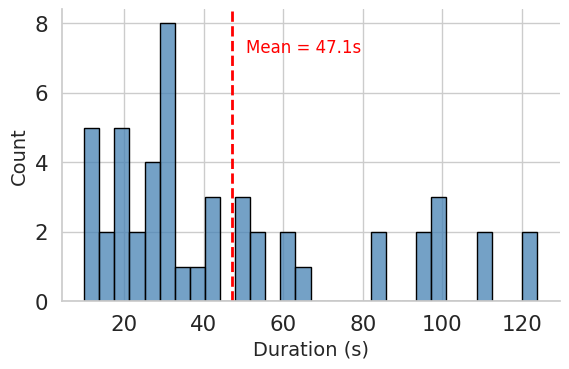

In [53]:
durations = dss['duration_s']
num_prims = dss['num_prims']

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(
    durations,
    bins=30,            # adjust depending on distribution
    kde=False,          # set True if you want smooth density curve
    color="steelblue",
    edgecolor="black",
    ax=ax
)
ax.set_xlabel("Duration (s)", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
# Optional: set tight x-limits if there are outliers
# ax.set_xlim(0, 200)
mean_val = np.mean(durations)
ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label="Mean")
ax.text(mean_val + 18, ax.get_ylim()[1]*0.9, f"Mean = {mean_val:.1f}s",
        color="red", ha="center", va="top", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import os
from tqdm import tqdm

# 2) walk through every entry’s label‐CSV, build a flat list of durations
paths = dss['path_l']
prim_durations = []
for csv_path in tqdm(paths):
    csv_path = os.path.join(DataPaths.RAW_LABEL_DIR, csv_path)
    hand = PrimitiveLabelUtils.get_handedness(csv_path)
    seq = PrimitiveLabelUtils.convert_labels_to_action_sequence(csv_path, hand)
    # pull out only the finite prim_durations
    prim_durations.extend(a['duration'] for a in seq if a['duration'] is not None)
    # for a in seq:
    #     if a['duration'] is None:
    #         print(f"Action {a} has no duration in path {csv_path}")
    #     elif a['duration'] > 10:
    #         print(f"Action {a} has duration {a['duration']} < 0.03 in path {csv_path}")
print(f"Percentage of durations below 0.03 seconds: {sum(d < 0.03 for d in prim_durations) / len(prim_durations) * 100:.2f}%")

100%|██████████| 50/50 [00:00<00:00, 98.33it/s]


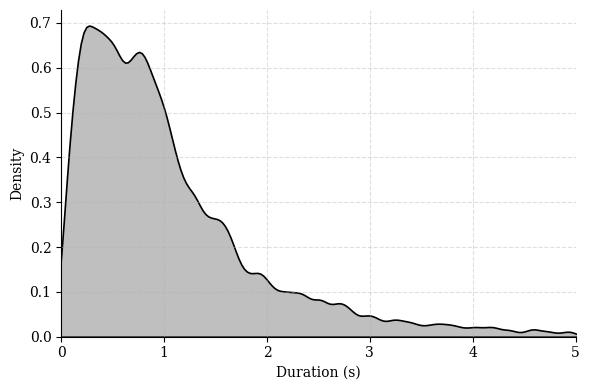

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Use serif font for publication style
mpl.rcParams.update({
    "font.family": "serif",
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.edgecolor": "black",
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# Filter durations
short_durations = [d for d in prim_durations if d < 5]

# KDE plot
plt.figure(figsize=(6, 4))
sns.kdeplot(short_durations, bw_adjust=0.5, fill=True, color="black", linewidth=1.2)

plt.xlabel("Duration (s)")
plt.ylabel("Density")
# plt.title("KDE of durations < 5 seconds", fontsize=14, fontweight='semibold')
plt.xlim(0, 5)
plt.grid(True)
plt.tight_layout()
# Save as PDF
plt.savefig("duration_kde.pdf", format='pdf', bbox_inches='tight')
# plt.show()

In [ ]:
import numpy as np
import pandas as pd

# 3) compute cumulative counts & percents at 0.1s bins
thresholds = np.arange(0.05, 1.1, 0.05)
thresholds = np.append(thresholds, 1. / 30)
thresholds = np.append(thresholds, 5)  # include 5 seconds as the last threshold
stats = []
for t in thresholds:
    cnt = sum(d <= t for d in prim_durations)
    pct = cnt / len(prim_durations) * 100
    stats.append({'≤ t (s)': round(t, 2), 'count': cnt, 'percent (%)': round(pct, 2)})

df_stats = pd.DataFrame(stats)

# 4) print the table
print(df_stats)

    ≤ t (s)  count  percent (%)
0      0.05    252         1.31
1      0.10    694         3.62
2      0.15   1185         6.18
3      0.20   1835         9.57
4      0.25   2620        13.66
5      0.30   3160        16.48
6      0.35   3772        19.67
7      0.40   4415        23.02
8      0.45   5046        26.31
9      0.50   5769        30.08
10     0.55   6284        32.76
11     0.60   6858        35.76
12     0.65   7402        38.59
13     0.70   7972        41.56
14     0.75   8653        45.11
15     0.80   9178        47.85
16     0.85   9742        50.79
17     0.90  10301        53.71
18     0.95  10819        56.41
19     1.00  11386        59.36
20     1.05  11799        61.52
21     0.03    157         0.82
22     5.00  18620        97.08


In [ ]:
max(prim_durations)

54.833

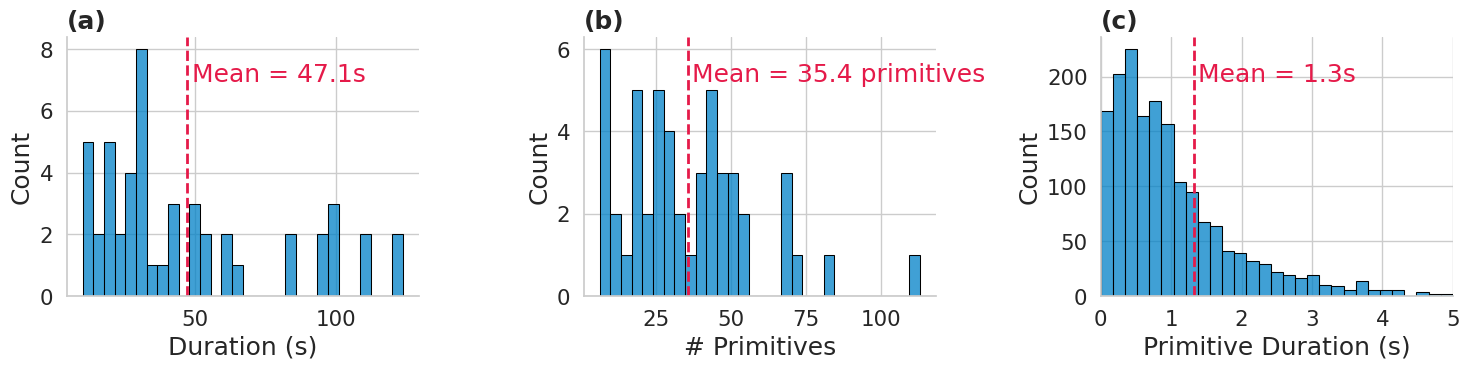

In [70]:
durations = dss['duration_s']
num_prims = dss['num_prims']
prim_durations = np.array(prim_durations)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

data_list = [durations, num_prims, prim_durations]
titles = ["Duration (s)", "# Primitives", "Primitive Duration (s)"]
text_labels = ["s", " primitives", "s"]
panel_tags = ['(a)', '(b)', '(c)']

for i, (ax, data, title, text_label, panel_tag) in enumerate(zip(axes, data_list, titles, text_labels, panel_tags)):
    if i == 2:
        # 🔹 Define bins only within 0–5
        bins = np.linspace(0, 5, 30)   # 30 bins between 0 and 5
        sns.histplot(
            data,
            bins=bins,
            color="#0081c7",
            edgecolor="black",
            ax=ax
        )
        ax.set_xlim(0, 5)
    else:
        sns.histplot(
            data,
            bins=30,
            color="#0081c7",
            edgecolor="black",
            ax=ax
        )

    mean_val = data.mean()
    ax.axvline(mean_val, color="#e51a49", linestyle="--", linewidth=2)
    ax.text(mean_val * 1.04, ax.get_ylim()[1]*0.9,
            f"Mean = {mean_val:.1f}{text_label}",
            color="#e51a49", ha="left", va="top", fontsize=18)

    ax.set_xlabel(title, fontsize=18)
    ax.set_ylabel("Count", fontsize=18)

    ax.set_title(panel_tag, loc="left", fontsize=18, fontweight="bold", pad=6)

sns.despine()
plt.tight_layout()
plt.savefig("histograms.pdf", bbox_inches="tight")
plt.show()

In [71]:
max(prim_durations)

40.99

In [ ]:
#e51a49